# Analyse de sensibilité de la traînée induite d'un avion

---
<div style="text-align: right;">
$\text{Mathias LOMMEL}$
</div>

<br>


<div style="text-align: right;">
$\textit{Mathématiques Appliquées - 5e année}$
</div>
<div style="text-align: right;">
$\textit{INSA Rennes}$
</div>

---

#### Importation des librairies

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import time
from IPython.display import clear_output

import openturns as ot
import openturns.viewer as otv
from openturns.viewer import View
import sys

ot.Log.Show(ot.Log.NONE)

## Cadre d'étude

Dans le cadre de cette application pratique, nous allons utiliser les méthodes vues en cours afin de réaliser une analyse de sensibilité sur un cas concret. A cet effet, nous allons considérer un cadre d'aérodynamique.

Lors du vol d'un avion, l'aile est soumise à une force de résistance à l'avancement. Cette force s'appelle la "traînée". Théoriquement, la traînée agit dans le sens opposé de l'écoulement d'air, tandis que la portance de l'aile agit perpendiculairement au flux d'air. Dans la réalité, la portance n'est pas tout à fait perpendiculaire à l'écoulement, et contribue alors à la traînée. Cette part de la traînée, induite par la portance, dépend de certaines caractéristiques de l'aile, notamment de son allongement et de la distribution de la portance en envergure. C'est ce que l'on appelle la "traînée induite".

![schema](trainee_image.png)

**$\to$ Qu'est-ce que la traînée induite ?**

Du fait de sa forme caractéristique, les écoulements d'air au dessus et en dessous de l'aile d'un avion sont très différents : on observe une surpression en dessous, et une dépression sur le dessus. C'est d'ailleurs cet écart de pression qui permet à l'avion de décoller.

Toutefois, les deux écoulements se rencontrent en bord de fuite, sous un certain angle, ce qui forme des tourbillons qui tournent dans le sens horaire  derrière l'aile gauche et dans le sens anti-horaire derrière l'aile droite. Ces tourbillons sont d'ailleurs parfois visibles grâce à la condensation de l'air, liée à la chute de pression au coeur du tourbillon.

Ces tourbillons ont un impact assez important : la portance, qui agit perpendiculairement à l'écoulement, s'incline légèrement vers l'arrière et contribue à la traînée. Cette partie de la traînée s'appelle la traînée induite.

![schema](schéma_trainée.png)

Les tourbillons produits en bout d'aile produisent donc des frottements supplémentaires, ce qui augmente inévitablement la consommation de l'appareil. Pour éviter cette problématique, il faudrait une aile infinie, ce qui est techniquement impossible. C'est pourquoi, les winglets ont été conçus pour casser cette tendance et réduire au maximum ces tourbillons.

Les constructeurs peuvent adopter différents modèles de « winglets » en fonction des avions.

![schema](tourbillons-marginaux.png)

**$\to$ Comment calculer la traînée induite ?**

Le calcul de la traînée induite (aussi appelée résistance induite), notée $R_i$, s'appuie sur la théorie des lignes portantes. Cette quantité peut être déterminée via la relation suivante :

$$
R_i = \frac{1}{2}.\rho.v^2.S.C_i
$$
Avec :
  - $\rho$ : masse volumique de l'air ($kg.m^{-3}$)
  - $v$ : vitesse de l'écoulement ($m.s^{-1}$)
  - $S$ : surface alaire ($m^2$)
  - $C_i$ : coefficient de traînée induite (sans dimension)

Nous travaillons avec une aile d'avion, qui un corps profilé. Nous pouvons donc appliquer la théorie des profils minces, ce qui nous permet de lier le coefficient de traînée induite au coefficient de portance, par :       
$$
C_i = \frac{C_z^2}{\pi.e.\lambda}
$$
Avec :     
  - $C_z$ : le coefficient de portance (sans dimension)
  - $e$ : coefficient d'Oswald (sans dimension)
  - $\lambda$ : allongement de l'aile (sans dimension)

L'allongement de l'aile s'exprime par $\lambda = \frac{b^2}{S_{ref}}$, avec $b$ l'envergure de l'aile, et $S_{ref}$ une surface de référence. Pour notre calcul, nous considèrerons $S_{ref}$ comme étant la surface frontale de l'aile (soit environ 1 mètre de hauteur, et b mètres de long). Nous pourrons donc simplement définir $S_{ref}$ comme étant $1.b = b$ (en $m^2$).


En prenant en compte ces résultats, nous obtenons finalement :      

$$
R_i = \frac{1}{2}.\rho.v^2.S.\frac{C_z^2}{\pi.e.\lambda} = \frac{1}{2}.\rho.v^2.S.\frac{C_z^2}{b.\pi.e}
$$
Avec :     
  - $\rho$ : masse volumique de l'air ($kg.m^{-3}$)
  - $v$ : vitesse de l'avion ($m.s^{-1}$)
  - $S$ : surface alaire ($m^2$)
  - $C_z$ : coefficient de portance (sans dimension)
  - $b$ : l'envergure de l'aile ($m$)
  - $e$ : coefficient d'Oswald (sans dimension)

**$\to$ Modélisation des variables d'entrée**

Nous obtenons donc une fonction dépendant de 5 paramètres : la vitesse $v$, la surface alaire $S$, le coefficient de portance $C_z$, l'envergure de l'avion $b$ et le coefficient d'Oswald $e$.

Pour notre cas d'étude, nous allons nous restreindre aux avions de lignes. Pour ce type d'avion, nous savons que :

$\to$ En vol de croisière, la vitesse de l'avion est comprise entre $820$ et $950$ km/h, soit entre $225$ et $265$ $m.s^{-1}$, et varie entre $250$ et $345$ km/h au décollage (soit entre $70$ et $95$ $m.s^{-1}$)

$\to$ La surface alaire $S$ peut varier entre $112$ et $850$ $m^2$.

$\to$ Le coefficient de portance $C_z$ varie entre $0.3$ et $0.7$ en vol de croisière, et peut atteindre $2.3$ à $2.7$ avec les systèmes hypersustentateurs (utilisés lors du décollage / atterrissage).

$\to$ L'envergure de l'aile $b$ s'étend de $35$ à $80$ $m$ environ.

$\to$ le coefficient d'Oswald $e$ varie entre $0.75$ et $0.85$.


Compte tenu de ces observations, on se propose de considérer les distributions suivantes :

$\to$ Pour la vitesse de l'avion : nous considèrerons que la vitesse suit une loi normale, de moyenne  $240$ en régime de croisière, et de moyenne $85$ au décollage. La variance sera choisie afin que la distribution varie majoritairement entre $225$ et $256$ $m.s^{-1}$ (resp. $70$ et $95$ $m.s^{-1}$).

$\to$ Pour la surface alaire : l'avion le plus répandu est l'Airbus A320, avec une surface alaire de $122$ $ m^2$. Nous proposons donc d'utiliser une loi Normale, centrée sur cette valeur avec un écart-type assez grand (autour de 300). Les valeurs seront tronquées entre les valeurs min et max énoncées précédemment.

$\to$ Pour le coefficient de portance : nous distinguerons 2 modes différents (Vol de croisière / décollage). Dans les deux cas, une loi uniforme sur le domaine de variation sera considérée.

$\to$ Pour l'envergure de l'aile : nous allons utiliser un raisonnement similaire à celui conduit pour la surface alaire. L'Airbus A320 ayant une envergure de $36$ $m$ environ, nous pouvons considérer une loi Normale centrée sur cette valeur, avec un écart-type élevé (autour de 20 par exemple).

$\to$ Pour le coefficient d'Oswald : comme pour le coefficient de portance, nous considèrerons une loi uniforme sur sa plage de valeurs.

On obtient finalement :

$$
\begin{array}{|c|c|}
\hline
\textbf{Variable} & \textbf{Loi et paramètres} \\
\hline
v & \mathcal{N}(\mu, \sigma),~avec ~~ (\mu, \sigma) \in \left\{ (240,10),(85,10) \right\}\\
\hline
S & \mathcal{N}(\mu=122,~ \sigma=300) \\
\hline
C_z & \mathcal{U}([l,u]),~avec ~~ (l,u) \in \left\{ (0.3,0.7),(2.3,2.7) \right\}\\
\hline
b & \mathcal{N}(\mu=36,~ \sigma=20) \\
\hline
e & \mathcal{U}(0.75,~ 0.85) \\
\hline
\end{array}
$$

Nous pouvons d'ailleurs visualiser les distributions proposées pour la surface alaire $S$, l'envergure de l'avion $b$, et de sa vitesse $v$.

Text(0.5, 1.0, "Vitesse de l'avion - décollage")

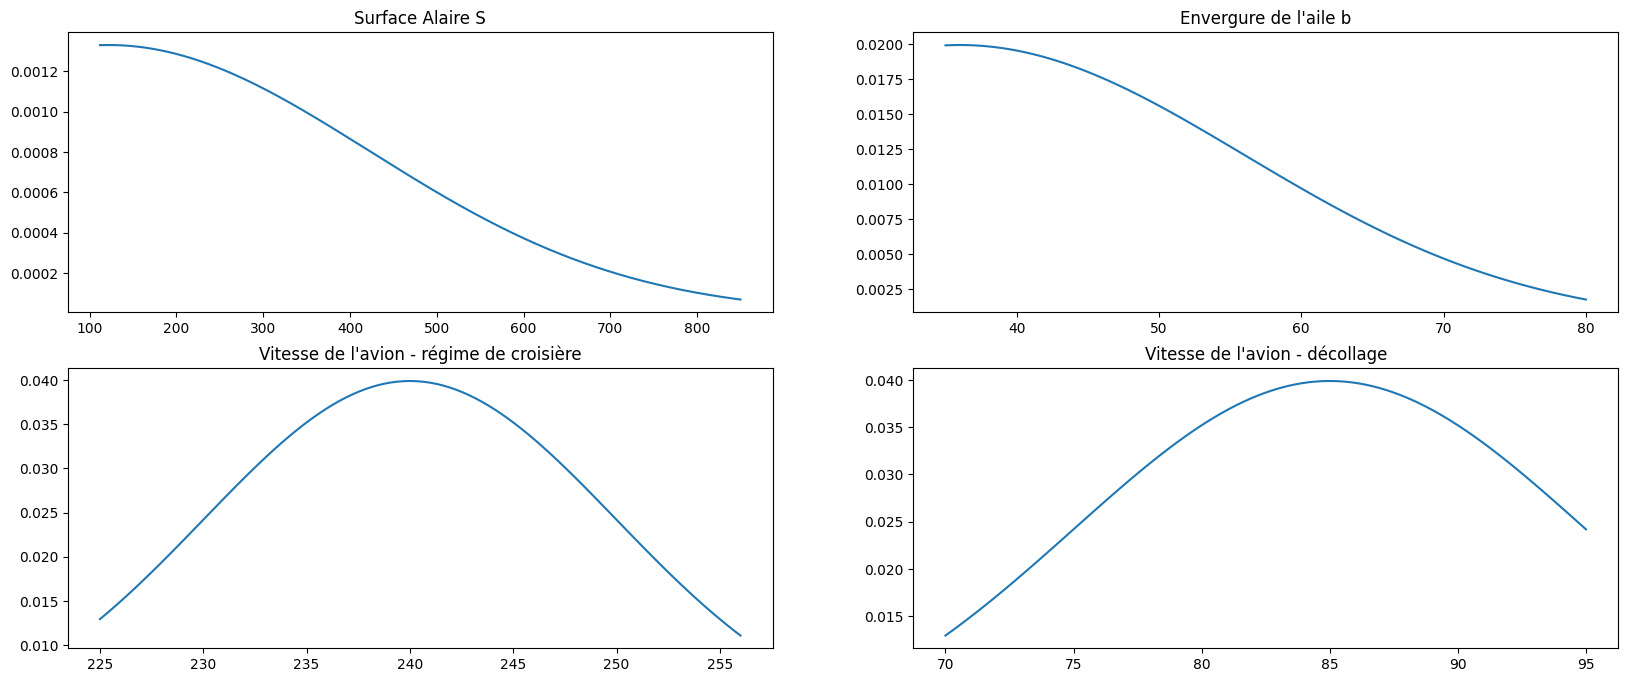

In [ ]:
_,axs = plt.subplots(2,2,figsize=(20,8))

x = np.linspace(112,850,800)
axs[0,0].plot(x, stats.norm.pdf(x,122,300))
axs[0,0].set_title("Surface Alaire S")

x = np.linspace(35,80,100)
axs[0,1].plot(x, stats.norm.pdf(x,36,20))
axs[0,1].set_title("Envergure de l'aile b")

x = np.linspace(225,256,100)
axs[1,0].plot(x, stats.norm.pdf(x,240,10))
axs[1,0].set_title("Vitesse de l'avion - régime de croisière")

x = np.linspace(70,95,100)
axs[1,1].plot(x, stats.norm.pdf(x,85,10))
axs[1,1].set_title("Vitesse de l'avion - décollage")

Bien entendu, cette modélisation simplifie grandement la réalité, puisqu'elle suppose qu'un avion peut combiner les différents paramètres ci-dessus. En pratique, il sera probablement impossible qu'un avion avec de grandes ailes puisse atteindre les vitesses les plus hautes par exemple. Nous garderons donc un esprit critique quant à l'ordre de grandeur de la traînée induite.

L'idée de ce travail étant d'étudier l'impact des entrées sur la sortie, nous n'accorderons pas une grande importance aux valeurs de la traînée induite en elle même, l'idée étant d'analyser l'impact des variables qui la définissent.

De plus, les distributions des différentes variables ont été choisies de manière assez arbitraire, en tenant compte des valeurs min/max et d'une moyenne basée sur l'avion le plus vendu dans le monde. N'ayant pas d'expert métier pour proposer de meilleures distributions d'entrées, nous nous contentetons de celles-ci pour notre cas d'étude.

## Analyse de sensibilité - Vol de croisière

Dans cette première partie, nous considérons le premier régime de fonctionnement de l'avion : en vol de croisière (faible coefficient de portance). Nous considèrerons donc une vitesse assez élevée, et un coefficient de portance relativement faible.


### Définition du modèle

Nous commençons par définir les distributions d'entrée, et nous construisons la fonction permettant de le calcul de la traînée induite.

In [ ]:
# Définition des distributions des variables (selon les lois présentées ci-dessus)
V = ot.Normal(240,10)      # Distribution de la vitesse en vol de croisière
S = ot.Normal(122,300)
C_z = ot.Uniform(0.3,0.7)  # Coefficient de portance en vol de croisière
b = ot.Normal(36,20)
e = ot.Uniform(0.75,0.85)

# Création de la loi conjointe à toutes les variables (hypothèse d'indépendance)
input_dist =  ot.JointDistribution([V,S,C_z,b,e])
input_dist.setDescription(["V","S", "Cz", "b", "e"])

In [ ]:
def Ri(X,reg):
  """
  Calcule la traînée induite à l'aide des entrées X

  Entrée :
    - X : ot.Sample - Données d'entrée de notre problème

  Sortie :
    - ri : ot.Sample - Données de sortie de notre problème
  """
  # Convertion de l'échantillon en array NumPy
  X = np.array(X)
  # Récupération des échantillons de chaque variable d'entrée
  if reg == "croisiere":
    V = np.clip(X[:,0],225,265)
  else:
    V = np.clip(X[:,0],70,95)

  S = np.clip(X[:,1],112,850)
  C_z = X[:,2]
  b = np.clip(X[:,3],35,80)
  e = X[:,4]

  # Calcul de la traînée induite
  ri = (1/2)*1.225*(V**2)*(S)*( (C_z**2) )/( b*np.pi*e)

  # Convertion de l'échantillon en Sample OpenTURNS
  ri = ot.Sample(ri.reshape(-1,1))

  return ri


### Génération et visualisation des échantillons

En simulant 1000 données d'entrée, nous obtenons un 1000-échantillon de traînées induites.

In [ ]:
# Noms des variables
inputNames = input_dist.getDescription()
print(inputNames)

# Simulation des entrées et des sorties
sampleSize = 1000
inputDesign = input_dist.getSample(sampleSize)

# On ajoute la sortie au tableau d'entrées
outputDesign = Ri(inputDesign,"croisiere")

# Récupération de la dimension du problème (nombre de variables d'entrée)
d = inputDesign.getDimension()
print("Problème à ",d," dimensions.")

[V,S,Cz,b,e]
Problème à  5  dimensions.


Nous pouvons d'ailleurs afficher la distribution des traînées induites simulées.

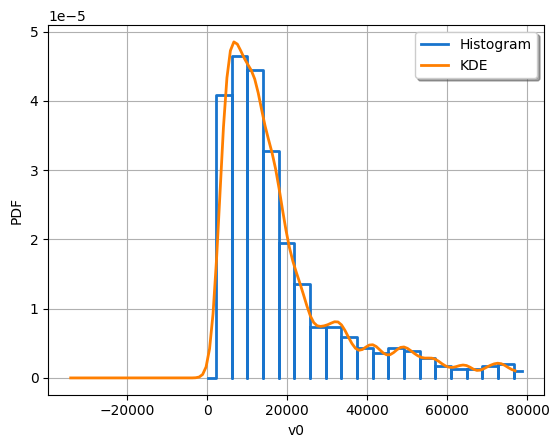

In [ ]:
# Affichage de l'histogramme
graph = ot.HistogramFactory().build(outputDesign).drawPDF()

# Affichage de la densité des sorties
kde = ot.KernelSmoothing()
fit = kde.build(outputDesign)
kde_curve = fit.drawPDF()

# Affichages
graph.add(kde_curve)
graph.setColors(["dodgerblue3", "darkorange1"])
graph.setLegends(["Histogram", "KDE"])
graph.setLegendPosition("topright")
graph.setTitle("")
view = otv.View(graph)

Une remarque, qui est assez intéressante d'un point de vue pratique, est que l'ordre de grandeur de la traînée induite semble correspondre aux ordre de grandeurs donnés par la littérature. Cela signifie que notre modèle ne simplifie "pas trop" la réalité, et ne déforme pas de manière significative la réalité, ce qui est rassurant.

### Analyse de sensibilité globale

Avant toutes choses, nous devons choisir des noyaux de covariance pour nos entrées, ainsi que pour notre sortie.
A défaut d'avoir accès à des données d'experts, nous utiliserons, un noyau de covariance de type "SquaredExponential". Nous utiliserons également ce noyau pour la covariance de la variable de sortie.

In [ ]:
# Création des noyaux de covariance des variables
covarianceModelCollection = []
for i in range(5):
    # Loi marginale de l'entrée
    Xi = inputDesign.getMarginal(i)
    # Choix du noyau gaussien
    inputCovariance = ot.SquaredExponential(1)
    # Recherche de l'hyperparamètre
    inputCovariance.setScale(Xi.computeStandardDeviation()) # Empirical estimate of the standard deviation
    # Ajout de la covariance à la liste
    covarianceModelCollection.append(inputCovariance)

# Choix du noyau de covariance pour la sortie
outputCovariance = ot.SquaredExponential(1)
outputCovariance.setScale(outputDesign.computeStandardDeviation())
covarianceModelCollection.append(outputCovariance)

Et nous pouvons ensuite réaliser une première analyse de sensibilité, dite "globale".

In [ ]:
estimatorType = ot.HSICUStat() # ot.HSICVStat()

# Création de l'analyse de sensibilité globale
GSAstudy = ot.HSICEstimatorGlobalSensitivity(
    covarianceModelCollection,
    inputDesign, outputDesign,
    estimatorType
)

In [ ]:
R2HSICIndices = GSAstudy.getR2HSICIndices()
print("(GSA study) R2-HSIC indices:\n", R2HSICIndices)

HSICIndices = GSAstudy.getHSICIndices()
print("(GSA study) HSIC Indices:\n", HSICIndices)

pvalAsymp = GSAstudy.getPValuesAsymptotic()
print("p-values (asymptotic):\n", pvalAsymp)

pvalPerm = GSAstudy.getPValuesPermutation()
print("p-values (permutation):\n", pvalPerm)


(GSA study) R2-HSIC indices:
 [0.000179607,0.434536,0.177322,0.0367261,-0.000906542]
(GSA study) HSIC Indices:
 [9.06297e-06,0.0209835,0.0105585,0.00188773,-5.3294e-05]
p-values (asymptotic):
 [0.374844,8.87357e-87,5.59561e-75,4.44867e-18,0.710387]
p-values (permutation):
 [0.326733,0,0,0,0.70297]


In [ ]:
def compute_graphs(study, d, asymptotic=1):
  """
  Construit les graphes issus de l'étude menée.

  Entrées :
    - study : Analyse de sensibilité réalisée
    - d     : Dimensionalité du problème

  Sorties :
    - graph_HSICindices   : Graphique des HSIC indices
    - graph_R2HSICIndices : Graphique des R2-HSIC indices
    - graph_pvalAsymp     : Graphique des p-values asymptotiques
    - graph_pvalPerm      : Graphique des p-values issues des permutations
  """
  ## HSIC indices
  graph_HSICindices = study.drawHSICIndices()
  graph_HSICindices.setColors(["brown", "black"])
  graph_HSICindices.setXTitle("inputs")
  graph_HSICindices.setYTitle("values of indices")
  graph_HSICindices.setTitle("GSA study - HSIC indices")

  ## R2-HSIC indices
  graph_R2HSICIndices = study.drawR2HSICIndices()
  graph_R2HSICIndices.setColors(["darkorange1", "black"])
  graph_R2HSICIndices.setXTitle("inputs")
  graph_R2HSICIndices.setYTitle("values of indices")
  graph_R2HSICIndices.setTitle("GSA study - R2-HSIC indices")

  # P-values issues des permutations
  graph_pvalPerm = study.drawPValuesPermutation()
  g = ot.SymbolicFunction("x","0.05") # Threshold 5%
  threshold_pval = g.draw(0,d)
  graph_pvalPerm.add(threshold_pval)
  graph_pvalPerm.setColors(["gray", "black", "red"])
  graph_pvalPerm.setXTitle("inputs")
  graph_pvalPerm.setYTitle("p-values")
  graph_pvalPerm.setTitle("GSA study - Permutation-based p-values")

  if asymptotic == 1:
    # P-values asymptotiques
    graph_pvalAsymp = study.drawPValuesAsymptotic()
    g = ot.SymbolicFunction("x","0.05") # Threshold 5%
    threshold_pval = g.draw(0,d)
    graph_pvalAsymp.add(threshold_pval)
    graph_pvalAsymp.setColors(["dodgerblue3", "black", "red"])
    graph_pvalAsymp.setXTitle("inputs")
    graph_pvalAsymp.setYTitle("p-values")
    graph_pvalAsymp.setTitle("GSA study - Asymptotic p-values")

    return graph_HSICindices, graph_R2HSICIndices, graph_pvalAsymp, graph_pvalPerm
  else:
    return graph_HSICindices, graph_R2HSICIndices, graph_pvalPerm

In [ ]:
def plot_graphs(graph1, graph2, graph3, graph4=None, asymptotic=1):
  """
  Affiche les graphiques souhaités.

  Entrées :
    - graph1, graph2, graph3, graph4 : Graphiques à afficher
  """
  if asymptotic == 1:
    # Affichage des graphiques
    fig = plt.figure(figsize=(18, 4))
    hsic = fig.add_subplot(1, 4, 1)
    hsic.set_title('HSIC Indices')
    _ = otv.View(graph1, figure=fig, axes=[hsic])
    r2hsic = fig.add_subplot(1, 4, 2)
    r2hsic.set_title('R2-HSIC Indices')
    _ = otv.View(graph2, figure=fig, axes=[r2hsic])
    pvalA = fig.add_subplot(1, 4, 3)
    pvalA.set_title('p-values Asymptotic')
    _ = otv.View(graph3, figure=fig, axes=[pvalA])
    pvalP = fig.add_subplot(1, 4, 4)
    pvalP.set_title('p-values Permutations')
    _ = otv.View(graph4, figure=fig, axes=[pvalP])
    _ = fig.suptitle("")
  else:
    # Affichage des graphiques
    fig = plt.figure(figsize=(14, 4))
    hsic = fig.add_subplot(1, 3, 1)
    hsic.set_title('HSIC Indices')
    _ = otv.View(graph1, figure=fig, axes=[hsic])
    r2hsic = fig.add_subplot(1, 3, 2)
    r2hsic.set_title('R2-HSIC Indices')
    _ = otv.View(graph2, figure=fig, axes=[r2hsic])
    pvalP = fig.add_subplot(1, 3, 3)
    pvalP.set_title('p-values Permutations')
    _ = otv.View(graph3, figure=fig, axes=[pvalP])

    _ = fig.suptitle("")

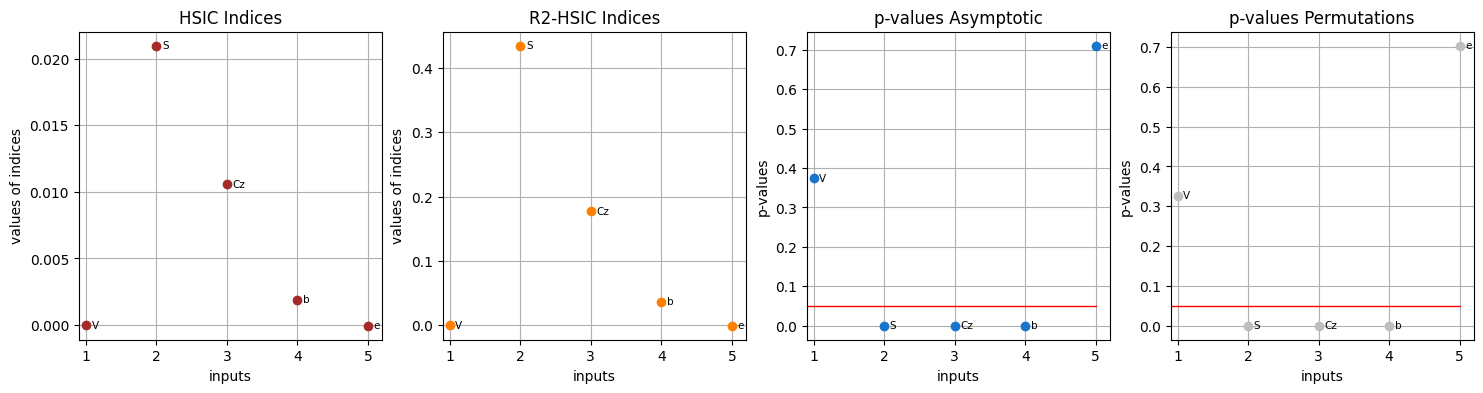

In [ ]:
g1, g2, g3, g4 = compute_graphs(GSAstudy, d=5)
plot_graphs(g1, g2, g3, g4)

A l'aide des graphiques de p-values, nous pouvons rejeter l'indépendance de la variable de sortie avec les variables $S$, $C_z$ et $b$.

Ainsi, 3 des 5 variables semblent être particulièrement influentes. Les deux autres variables ($v$ et $e$) ont une p-value bien supérieure au seuil considéré (de 5\%), et ne peuvent donc pas être considérées comme statistiquement influentes sur la traînée induite.

Pour s'assurer que nos conclusions ne soient pas spécifiques à nos échantillons simulés, nous pouvons ajouter un intervalle de confiance aux indices HSIC et aux p-values. Ceux-ci seront obtenus par $Bootstrap$, puisque nous ne disposons que d'un seul échantillon de données.

Text(0.5, 1.0, 'Asymptotic p-values')

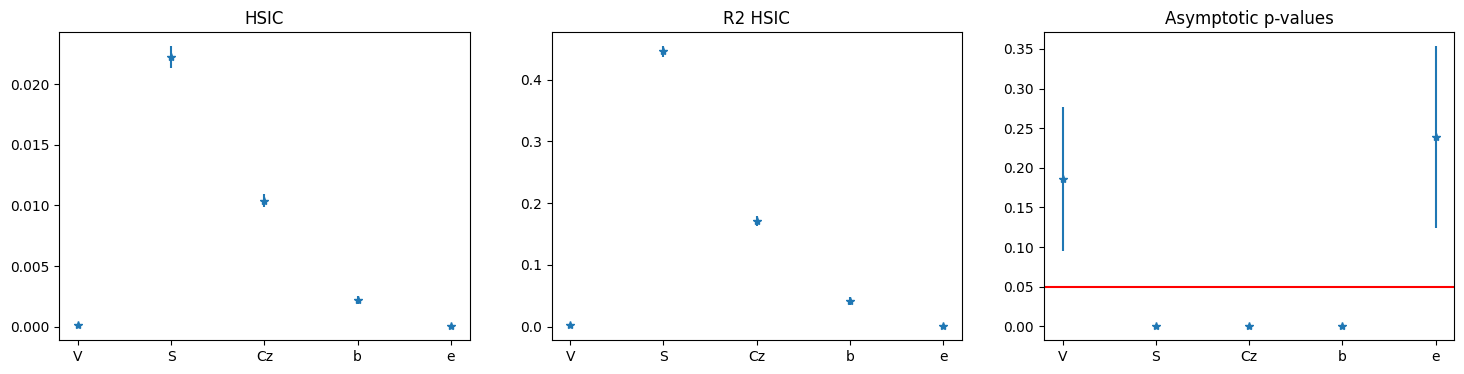

In [ ]:
copy_inputDesign = inputDesign
copy_outputDesign = outputDesign
totalSample = copy_inputDesign
totalSample.stack(copy_outputDesign)
experiment = ot.BootstrapExperiment(totalSample)
nboot = 10

boot_HSIC = ot.Sample(0,5)
boot_R2HSIC = ot.Sample(0,5)
boot_pvalAsymp = ot.Sample(0,5)

for i in range(nboot):
    # We generate the bootstrap sample
    bootstrapSample = experiment.generate()
    bootstrapInput = bootstrapSample[:,:5]
    bootstrapOutput = bootstrapSample[:,-1]

    # We compute the HSIC indices
    GSAstudy = ot.HSICEstimatorGlobalSensitivity(
      covarianceModelCollection, bootstrapInput, bootstrapOutput,estimatorType)
    boot_HSIC.add(GSAstudy.getHSICIndices())
    boot_R2HSIC.add(GSAstudy.getR2HSICIndices())
    boot_pvalAsymp.add(GSAstudy.getPValuesAsymptotic())

_, axs = plt.subplots(1,3,figsize=(18,4))

boot_HSIC = np.array(boot_HSIC)
axs[0].errorbar(np.arange(5), np.mean(boot_HSIC, axis = 0), np.std(boot_HSIC, axis = 0)/2, fmt = '*')
axs[0].set_xticks(np.arange(5), input_dist.getDescription())
axs[0].set_title('HSIC')

boot_R2HSIC = np.array(boot_R2HSIC)
axs[1].errorbar(np.arange(5), np.mean(boot_R2HSIC, axis = 0), np.std(boot_R2HSIC, axis = 0)/2, fmt = '*')
axs[1].set_xticks(np.arange(5), input_dist.getDescription())
axs[1].set_title('R2 HSIC')

boot_pvalAsymp = np.array(boot_pvalAsymp)
axs[2].errorbar(np.arange(5), np.mean(boot_pvalAsymp, axis = 0), np.std(boot_pvalAsymp, axis = 0)/2, fmt = '*')
axs[2].set_xticks(np.arange(5), input_dist.getDescription())
axs[2].axhline(y=0.05,color='red')
axs[2].set_title('Asymptotic p-values')

Les conclusions précédentes ne semblent pas être remises en causes par ce nouveau graphique. En effet, les intervalles de confiance des variables $v$ et $e$ restent bien au dessus du seuil. Ces variables peuvent donc être considérée comme faiblement influentes sur la variable réponse, et ce avec une assurance assez grande.

La traînée induite varie donc majoritairement en fonction des caractéristiques de l'avion (surface alaire et envergure), mais aussi du coefficient de portance (qui lui dépend également de la forme de l'aile).

### Analyse de sensibilité conditionnelle


Les indices HSIC standard permettent d'évaluer l'influence des variables d'entrée sur toute la distribution de sortie. Dans l'analyse précédente, nous avons pu établier ces influences sur notre cas d'étude.

Toutefois, il serait intéressant de voir l'évolution de ces influences lorsque la valeur de la traînée induite varie. En particulier, nous souhaiterions analyser ces influences pour des valeurs de traînée élevées.

Pour faire cela, nous pouvons analyser les indices HSIC conditionnels (C-HSIC), qui caractérisent l'influence des variables d'entrée dans un domaine critique donné. Nous nous placerons dans le domaine de traînée induite haute (10% des traînées induites les plus grandes). Dans notre cas, cette valeur seuil se trouve autour de $50~kN$.

Nous définirons ici une fonction filtre, qui transforme les valeurs de sortie en fonction de leur distance par rapport au domaine critique.

In [ ]:
# Création du seuil critique au delà de 90% des traînées induites les plus hautes
criticalThreshold = np.percentile(outputDesign, 90)
print(criticalThreshold)
criticalDomain = ot.Interval(criticalThreshold, float("inf"))

# Création de la fonction de filtre
dist2criticalDomain = ot.DistanceToDomainFunction(criticalDomain)
f = ot.SymbolicFunction(["x", "s"], ["exp(-x/s)"])
phi = ot.ParametricFunction(f, [1], [0.1 * outputDesign.computeStandardDeviation()[0]])
filterFunction = ot.ComposedFunction(phi, dist2criticalDomain)

48654.09290227091


In [ ]:
CSAstudy = ot.HSICEstimatorConditionalSensitivity(
    covarianceModelCollection, inputDesign[:,0:5], outputDesign, filterFunction
)

C_HSICIndices = CSAstudy.getHSICIndices()
print("(CSA study) C-HSIC Indices:\n", C_HSICIndices)

C_R2HSICIndices = CSAstudy.getR2HSICIndices()
print("(CSA study) T-HSIC Indices:\n", C_R2HSICIndices)

C_pvalPerm = CSAstudy.getPValuesPermutation()
print("(CSA study) p-values (permutation):\n", C_pvalPerm)

(CSA study) C-HSIC Indices:
 [0.0014039,0.0193645,0.00437042,0.00285728,0.00176252]
(CSA study) T-HSIC Indices:
 [0.0185988,0.33113,0.0781658,0.0427899,0.0200749]
(CSA study) p-values (permutation):
 [0.49505,0,0.019802,0.108911,0.39604]


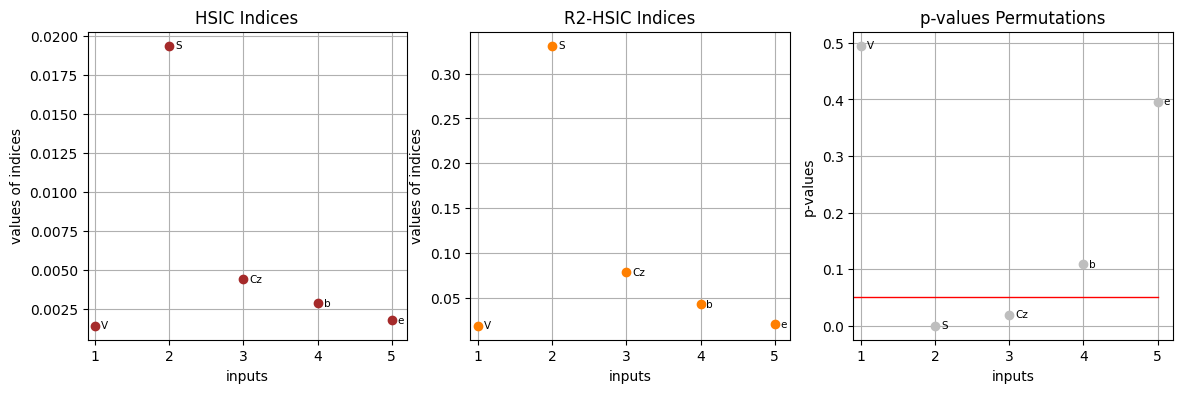

In [ ]:
g1, g2, g3 = compute_graphs(CSAstudy, d=5, asymptotic=0)
plot_graphs(g1, g2, g3, asymptotic=0)

Comme nous pouvons le remarquer, les résultats sont assez différents des précédents. Il semblerait ici que l'envergure de l'avion n'ait plus influence significative sur la variable réponse. Ainsi, pour des valeurs de traînée assez hautes, la surface alaire et le coefficient de portance sont les deux facteurs les plus influents.

Cette analyse est intéressante, puisqu'elle permet de voir que l'influence des variables d'entrée dépend de l'ordre de grandeur de la variable réponse : ici, pour des valeurs moyenne de traînée induite, l'envergure est influente, alors qu'elle ne l'est statistiquement pas pour des valeurs extrêmes de traînée.

## Analyse de sensibilité - Décollage de l'avion

Cette fois, nous allons réaliser les mêmes analyses, mais cette fois en considérant un avion au décollage. Durant cette phase, nous avons pu voir que 2 variables sont impactées : la vitesse de l'avion, divisée par un facteur 3 environ, et le coefficient de portance, qui est entre 7 et 8 fois supérieur. Les autres variables restent cependant inchangées.

Dans cette partie, nous allons donc générer un nouvel échantillon, de taille 1000, avec les nouvelles distributions des variables d'entrée.

### Définition des distributions d'entrée

Comme pour le cas précédent, nous générons un 1000-échantillon pour les variables d'entrée, et nous obtenons un 1000-échantillon de traînées induites.

In [ ]:
# Définition des distributions des variables (selon les lois présentées ci-dessus)
V = ot.Normal(85,10)      # Distribution de la vitesse en vol de croisière
S = ot.Normal(122,300)
C_z = ot.Uniform(2.3,2.7)  # Coefficient de portance en vol de croisière
b = ot.Normal(36,20)
e = ot.Uniform(0.75,0.85)

# Création de la loi conjointe à toutes les variables (hypothèse d'indépendance)
input_dist =  ot.JointDistribution([V,S,C_z,b,e])
input_dist.setDescription(["V","S", "Cz", "b", "e"])

[V,S,Cz,b,e]
Problème à  5  dimensions.


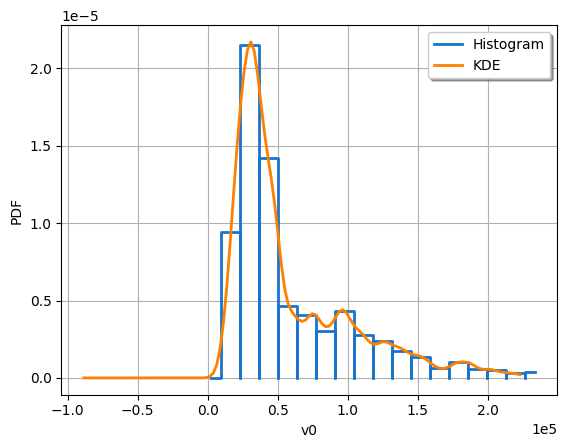

In [ ]:
# Noms des variables
inputNames = input_dist.getDescription()
print(inputNames)

# Simulation des entrées et des sorties
sampleSize = 1000
inputDesign = input_dist.getSample(sampleSize)

# On ajoute la sortie au tableau d'entrées
outputDesign = Ri(inputDesign,"decollage")

# Récupération de la dimension du problème (nombre de variables d'entrée)
d = inputDesign.getDimension()
print("Problème à ",d," dimensions.")

# Affichage de l'histogramme
graph = ot.HistogramFactory().build(outputDesign).drawPDF()

# Affichage de la densité des sorties
kde = ot.KernelSmoothing()
fit = kde.build(outputDesign)
kde_curve = fit.drawPDF()

# Affichages
graph.add(kde_curve)
graph.setColors(["dodgerblue3", "darkorange1"])
graph.setLegends(["Histogram", "KDE"])
graph.setLegendPosition("topright")
graph.setTitle("")
view = otv.View(graph)

Qui dit distributions d'entrée différentes, dit distribution de sortie différente. En effet, dans notre cas, le changement de régime d'étude modifie légèrement la valeur de la traînée induite.

En effet, la traînée induite a presque été multipliée par 5. Cette variation s'explique simplement par la forte augmentation du coefficient de portance, qui, comme nous l'avons dit précédemment, est ici multiplié par 7 environ (cette augmentation compense donc la diminution de la vitesse).

### Analyse de sensibilité globale

Comme pour le cas précédent, nous pouvons commencer par une analyse globale de ce second régime de fonctionnement de l'avion.

In [ ]:
estimatorType = ot.HSICUStat() # ot.HSICVStat()

# Création de l'analyse de sensibilité globale
GSAstudy_decollage = ot.HSICEstimatorGlobalSensitivity(
    covarianceModelCollection,
    inputDesign, outputDesign,
    estimatorType
)

R2HSICIndices = GSAstudy_decollage.getR2HSICIndices()
print("(GSA study) R2-HSIC indices:\n", R2HSICIndices)

HSICIndices = GSAstudy_decollage.getHSICIndices()
print("(GSA study) HSIC Indices:\n", HSICIndices)

pvalAsymp = GSAstudy_decollage.getPValuesAsymptotic()
print("p-values (asymptotic):\n", pvalAsymp)

pvalPerm = GSAstudy_decollage.getPValuesPermutation()
print("p-values (permutation):\n", pvalPerm)



(GSA study) R2-HSIC indices:
 [0.0334561,0.566636,0.0103288,0.0404691,-0.0003647]
(GSA study) HSIC Indices:
 [0.00270206,0.0452503,0.000972437,0.00322657,-3.29746e-05]
p-values (asymptotic):
 [8.0389e-19,2.37784e-239,9.99109e-06,7.02412e-23,0.534477]
p-values (permutation):
 [0,0,0,0,0.574257]


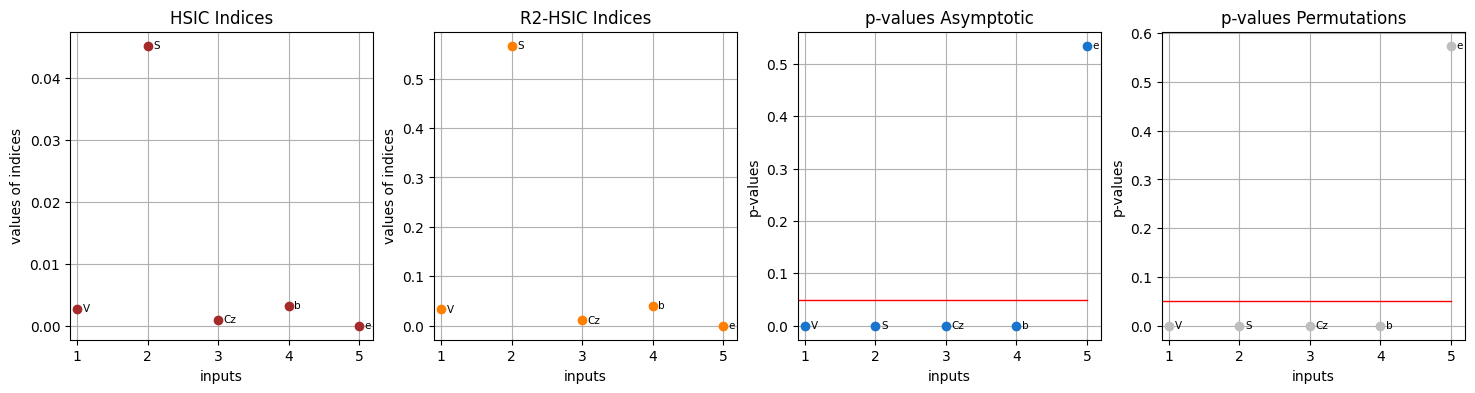

In [ ]:
g1, g2, g3, g4 = compute_graphs(GSAstudy_decollage, d=5)
plot_graphs(g1, g2, g3, g4)

Text(0.5, 1.0, 'Asymptotic p-values')

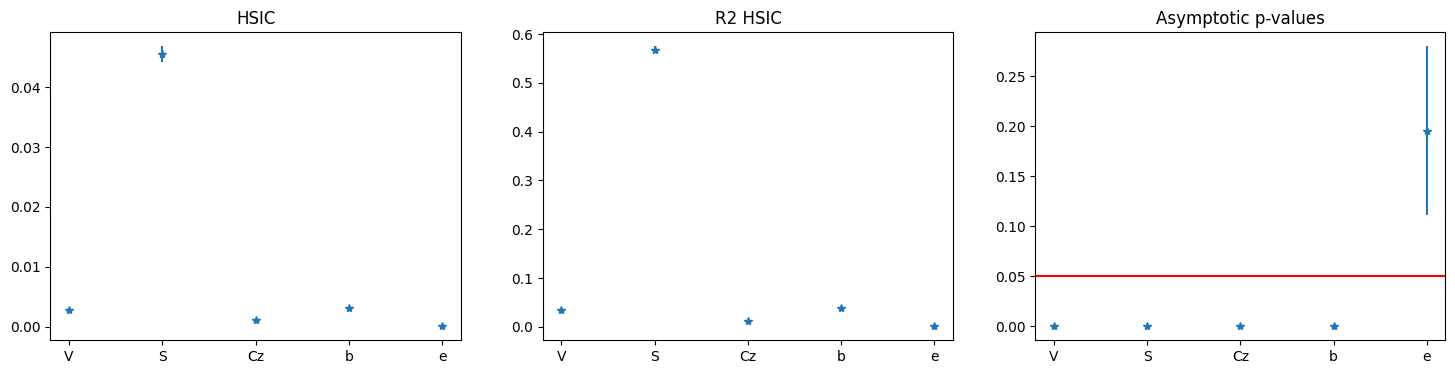

In [ ]:
inputDesign_copy = inputDesign
outputDesign_copy = outputDesign
totalSample = inputDesign_copy
totalSample.stack(outputDesign_copy)
experiment = ot.BootstrapExperiment(totalSample)
nboot = 10

boot_HSIC = ot.Sample(0,5)
boot_R2HSIC = ot.Sample(0,5)
boot_pvalAsymp = ot.Sample(0,5)

for i in range(nboot):
    # We generate the bootstrap sample
    bootstrapSample = experiment.generate()
    bootstrapInput = bootstrapSample[:,:5]
    bootstrapOutput = bootstrapSample[:,-1]

    # We compute the HSIC indices
    GSAstudy_decollage_boot = ot.HSICEstimatorGlobalSensitivity(
      covarianceModelCollection, bootstrapInput, bootstrapOutput,estimatorType)
    boot_HSIC.add(GSAstudy_decollage_boot.getHSICIndices())
    boot_R2HSIC.add(GSAstudy_decollage_boot.getR2HSICIndices())
    boot_pvalAsymp.add(GSAstudy_decollage_boot.getPValuesAsymptotic())

_, axs = plt.subplots(1,3,figsize=(18,4))

boot_HSIC = np.array(boot_HSIC)
axs[0].errorbar(np.arange(5), np.mean(boot_HSIC, axis = 0), np.std(boot_HSIC, axis = 0)/2, fmt = '*')
axs[0].set_xticks(np.arange(5), input_dist.getDescription())
axs[0].set_title('HSIC')

boot_R2HSIC = np.array(boot_R2HSIC)
axs[1].errorbar(np.arange(5), np.mean(boot_R2HSIC, axis = 0), np.std(boot_R2HSIC, axis = 0)/2, fmt = '*')
axs[1].set_xticks(np.arange(5), input_dist.getDescription())
axs[1].set_title('R2 HSIC')

boot_pvalAsymp = np.array(boot_pvalAsymp)
axs[2].errorbar(np.arange(5), np.mean(boot_pvalAsymp, axis = 0), np.std(boot_pvalAsymp, axis = 0)/2, fmt = '*')
axs[2].set_xticks(np.arange(5), input_dist.getDescription())
axs[2].axhline(y=0.05,color='red')
axs[2].set_title('Asymptotic p-values')

Ici, à l'inverse de l'analyse en vol de croisière, seul le coefficient d'Oswald n'est pas statistiquement influent sur la traînée induite. Ainsi, au cours du décollage, la vitesse a un influence, là où elle n'en n'avait pas au cours d'un vol de croisière.

### Analyse de sensibilité conditionnelle

Enfin, comme pour le cas précédent, nous pouvons réaliser une dernière analyse, sur les 10\% des plus grandes traînées observées lors du décollage.

Cette fois, la valeur seuil se situe autour de $130~kN$ (environ 2.5x plus élevée qu'en vol de croisière).

In [ ]:
# Création du seuil critique au delà de 90% des traînées induites les plus hautes
criticalThreshold = np.percentile(outputDesign, 90)
print(criticalThreshold)
criticalDomain = ot.Interval(criticalThreshold, float("inf"))

# Création de la fonction de filtre
dist2criticalDomain = ot.DistanceToDomainFunction(criticalDomain)
f = ot.SymbolicFunction(["x", "s"], ["exp(-x/s)"])
phi = ot.ParametricFunction(f, [1], [0.1 * outputDesign.computeStandardDeviation()[0]])
filterFunction = ot.ComposedFunction(phi, dist2criticalDomain)

130845.52934007945


(CSA study) C-HSIC Indices:
 [0.00252368,0.0103,0.00189972,0.00371511,0.00212549]
(CSA study) T-HSIC Indices:
 [0.0305331,0.217309,0.0188902,0.0599405,0.0218131]
(CSA study) p-values (permutation):
 [0.306931,0,0.514851,0.0990099,0.415842]


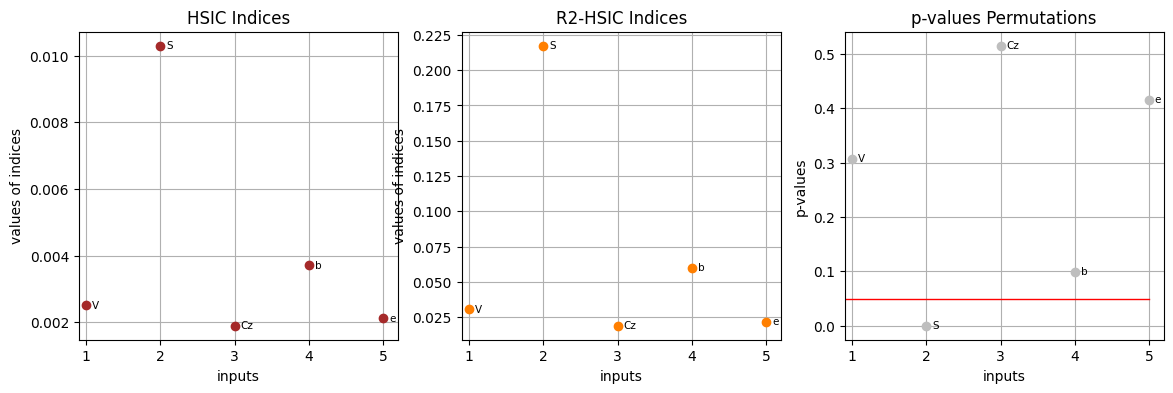

In [ ]:
CSAstudy_decollage = ot.HSICEstimatorConditionalSensitivity(
    covarianceModelCollection, inputDesign[:,0:5], outputDesign, filterFunction
)

C_HSICIndices = CSAstudy_decollage.getHSICIndices()
print("(CSA study) C-HSIC Indices:\n", C_HSICIndices)

C_R2HSICIndices = CSAstudy_decollage.getR2HSICIndices()
print("(CSA study) T-HSIC Indices:\n", C_R2HSICIndices)

C_pvalPerm = CSAstudy_decollage.getPValuesPermutation()
print("(CSA study) p-values (permutation):\n", C_pvalPerm)

g1, g2, g3 = compute_graphs(CSAstudy_decollage, d=5, asymptotic=0)
plot_graphs(g1, g2, g3, asymptotic=0)

Comme nous pouvons le remarquer sur le graphique ci-contre, seule la surface alaire semble être statistiquement influente. Ceci signifie que les fortes valeurs de traînée induite lors du décollage s'expliquent majoritairement par la surface des ailes.

## Conclusion

Au cours de cette application pratique, nous avons pu comparer l'influence de 5 variables d'entrées sur une variable de sortie. Nous avons analysé 2 régimes de fonctionnement de l'avion, et, pour chaque régime, nous avons analysé l'influence des variables d'entrées dans un cadre standard, et dans un cas extrême (hautes valeurs de traînée).

Les différentes analyses nous ont permis d'observer que, dans tous les cas, le coefficient d'Oswald n'influence pas significativement la valeur de la traînée induite.

Les 4 autres variables ont cependant été considérées comme significativement influentes dans au moins un des cas présenté ci-dessus. En particulier :

$\to$ La surface alaire $S$ est la variable centrale, qui influence la traînée induite dans tous les cas de figures. Ceci signifie que la traînée est très sensible à la valeur de cette surface.

$\to$ Le coefficient de portance $C_z$ est influent dans 3 des 4 cas identifiés. C'est d'ailleurs cette valeur qui est à l'origine de la différence, en ordre de grandeur, de la traînée induite en vol de croisière et lors du décollage.

$\to$ L'envergure de l'avion $b$ n'est influente qu'en cas de traînée "standard". En effet, dès lors que la traînée est extrême (dans les 10\% les plus hautes), cette variable d'entrée ne l'influence plus de manière significative.

$\to$ Et enfin, la vitesse de l'avion s'avère être influente uniquement lors du décollage, et pour des valeurs "standard" de traînée.

Dans une problématique de diminution des pertes énergétiques liées à cette traînée induite, le choix de la surface alaire semble donc être central. De plus, du fait de la faible durée du décollage, il semble être plus  judicieux de diminuer la traînée lors du vol de croisière. Pour diminuer ces pertes, il faudra combiner un bon ajustement de la surface de l'aile, de sa forme (qui modifiera $C_z$), et de sa longueur. En particulier, le travail devra principalement se focaliser sur la surface et la forme de l'aile, qui ont une influence majeure sur les fortes valeurs de traînée induite (synonymes de grandes pertes énergétiques et donc financières).

Cette mise en pratique a donc été un moyen d'approfondir les concepts théoriques vus en classe. Mais, au delà de l'aspect mathématique des analyses réalisées, ce travail pratique a été l'occasion d'étudier de manière plus approfondie une équation physique, en passant par son calcul, son interprétation, et en terminant avec l'analyse des liens entre les variables d'entrée et la variable de sortie.

De mon point de vue, ce travail a été très stimulant, et m'a permis de travailler sur un domaine d'application qui me semble intéressant. J'ai d'ailleurs particulièrement aimé chercher, comprendre et construire la formule physique sur laquelle toutes les analyses allaient être réalisées.